# Energy in the News: Changes in 2022–2024
**Author: Lilia Erofeevskaya**

This study examines changes in the frequency and tone of six energy-related topics in GDELT, their co-movement, and changes coinciding with major events.

## Main findings

Green energy and climate policy are strongly correlated in frequency, but less strongly in tone. Around 24 February 2022, the model identifies increases in the conflict and sanctions counts. Around COP summits, the largest positive coefficient corresponds to the first week. The predictive value of tone remains inconclusive: the daily VAR models fail residual whiteness tests.

The calculations and limitations of each finding are presented below.

## 1. Data and Methods

The main file, `data/raw/gdelt_energy_daily.csv`, contains one row per day, six topic counts (`count`), and six mean tone values (`tone`). A separate geographic aggregation is stored in `country_article_counts.csv`.

- **Frequency** is the topic count in the export. Without the underlying records, it cannot be established whether this equals the number of unique articles.
- **Tone** is the mean document-level AvgTone. It describes the whole text, rather than readers’ attitudes or the author’s position on a particular technology.
- Topics overlap and cannot be added as independent components of the news flow. Total daily news volume is unavailable, so topic shares are not calculated.
- The labels “sanctions and energy” and “conflict and energy” are provisional: the legacy regular expressions have not been validated against article texts. “Oil and gas” does not imply a separate filter for news about Russia.
- [Project SQL](../sql/gdelt_energy_unified.sql).

In [1]:
from pathlib import Path

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent

%pip install -r "{root / 'requirements.txt'}"


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: /Users/lilia/VScode/gdelt-media-energy-analysis/gdelt-media-energy-analysis/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import os, sys, warnings
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.matplotlib-cache'))
warnings.filterwarnings('ignore', message='adfuller currently returns a plain tuple', category=FutureWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown
from src.analysis import (TOPICS, load_daily_data, summarize_quality, benjamini_hochberg,
    differenced_topic_correlations, event_study_hac, event_study_level_hac)
from src.advanced_models import multi_event_distributed_lag, cop_event_time_model, var_changes_by_topic
LABELS = dict(zip(TOPICS, ['Oil and gas', 'Nuclear power', 'Green energy',
    'Climate policy', 'Sanctions and energy', 'Conflict and energy']))
BLUE = '#356a96'
CMAP = LinearSegmentedColormap.from_list('signed', [BLUE, '#fafafa', '#bc7132'])
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':10})
FIGURES, TABLES = ROOT/'reports/figures', ROOT/'reports/tables'
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)
def note(s): display(Markdown(s))
def finish(fig, name, rect=None):
    if name in ('02_frequency','03_tone'):
        for ax in fig.axes:
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m.%Y'))
            ax.set_xlim(pd.Timestamp('2022-01-01'), pd.Timestamp('2024-12-31'))
    fig.tight_layout(rect=rect)
    fig.savefig(FIGURES/(name+'.png'), dpi=130, bbox_inches='tight')
    plt.show()
    plt.close(fig)
def heatmap(matrix, title, name):
    fig, ax = plt.subplots(figsize=(9,7))
    im = ax.imshow(matrix, cmap=CMAP, vmin=-1, vmax=1)
    labels = [LABELS[c.rsplit('_',1)[0]] for c in matrix.columns]
    ax.set_xticks(range(6), labels, rotation=40, ha='right')
    ax.set_yticks(range(6), labels)
    ax.grid(False)
    for i in range(6):
        for j in range(6):
            ax.text(j,i,f'{matrix.iloc[i,j]:.2f}',ha='center',va='center',
                    color='white' if abs(matrix.iloc[i,j])>.7 else '#202020')
    ax.set_title(title+'\nDaily observations, 2022–2024')
    fig.colorbar(im, ax=ax, shrink=.8, label='Pearson r')
    finish(fig,name)
data = load_daily_data(ROOT/'data/raw/gdelt_energy_daily.csv')
country = pd.read_csv(ROOT/'data/raw/country_article_counts.csv')
count_cols, tone_cols = [[t+'_'+s for t in TOPICS] for s in ('count','tone')]

### 1.1. Data Validation

In [3]:
quality = summarize_quality(data)
assert quality.rows == 1096 and quality.missing_days == 0
assert quality.start_date == pd.Timestamp('2022-01-01') and quality.end_date == pd.Timestamp('2024-12-31')
assert quality.duplicate_dates == 0 and quality.missing_values == 0
assert country.country_code.notna().all() and country.country_code.is_unique
assert country.country_code.str.fullmatch('[A-Z]{2}').all()
assert (country.article_count >= 0).all() and (country.article_count % 1 == 0).all()
display(pd.Series(quality.__dict__, name='Result').to_frame())
display(data.head(3))

,Result
rows,1096
columns,13
start_date,2022-01-01 00:00:00
end_date,2024-12-31 00:00:00
missing_days,0
duplicate_dates,0
missing_values,0


,date,fossil_energy_count,fossil_energy_tone,nuclear_power_count,nuclear_power_tone,green_energy_count,green_energy_tone,climate_policy_count,climate_policy_tone,sanctions_energy_count,sanctions_energy_tone,conflict_energy_count,conflict_energy_tone
0,2022-01-01,4263,-0.298259,598,-1.237804,768,-0.039658,2889,-1.249151,1150,-2.343821,2628,-0.649498
1,2022-01-02,4185,-0.586491,559,-1.459046,1057,-0.917713,2928,-1.575082,644,-2.312528,2360,-1.011077
2,2022-01-03,7186,-0.757534,656,-1.548203,1322,0.283658,3422,-1.066548,1243,-2.099942,3663,-1.284629


The dataset contains 1,096 days with no gaps, duplicate dates, or missing values. Counts are non-negative integers, and tone values lie between −100 and 100. These checks establish basic suitability for daily time-series analysis; they do not establish the completeness of GDELT coverage or the accuracy of the topic definitions.

### 1.2. Geographic Mentions

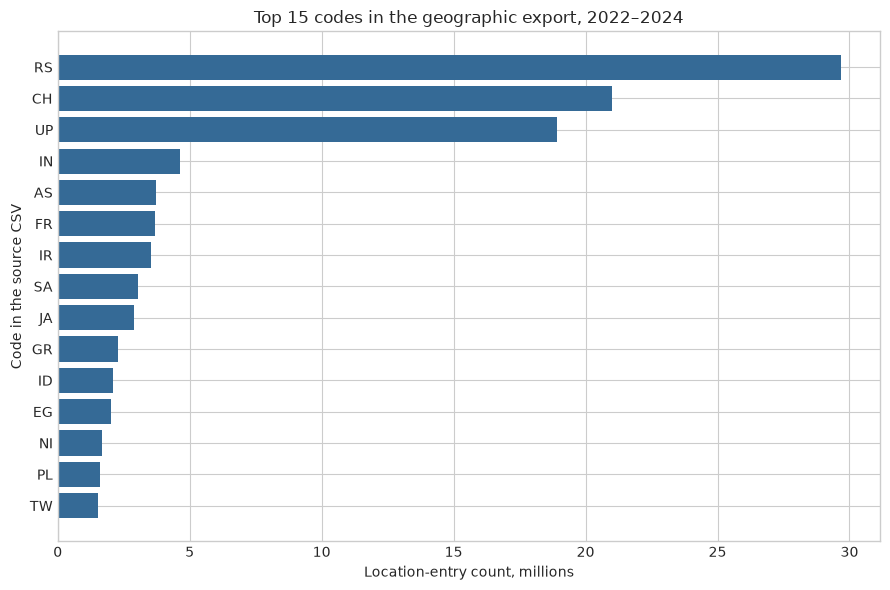

In [4]:
top = country.nlargest(15,'article_count').sort_values('article_count')
fig,ax = plt.subplots(figsize=(9,6))
ax.barh(top.country_code,top.article_count/1e6,color=BLUE)
ax.set(title='Top 15 codes in the geographic export, 2022–2024',
       xlabel='Location-entry count, millions',ylabel='Code in the source CSV')
finish(fig,'01_geography')
leaders = country.nlargest(3,'article_count')


The largest geographic counts are RS: 29.67 million, CH: 21.00 million, and UP: 18.91 million. Expanding location entries in SQL can count the same article more than once. The regular expression used in the original export also limits which entries are extracted. These figures represent location-entry counts and cannot be interpreted as unique article counts or the geographic distribution of news outlets. This table is not used in H1–H4.

The current SQL extracts country codes by field position and uses a shared document filter for both results. The existing CSV was exported earlier and has not been regenerated.

## 2. Temporal Patterns
### 2.1. Frequency Trends

The charts use trailing 14-day means to smooth weekly fluctuations, introducing some delay. The models use the original daily observations.

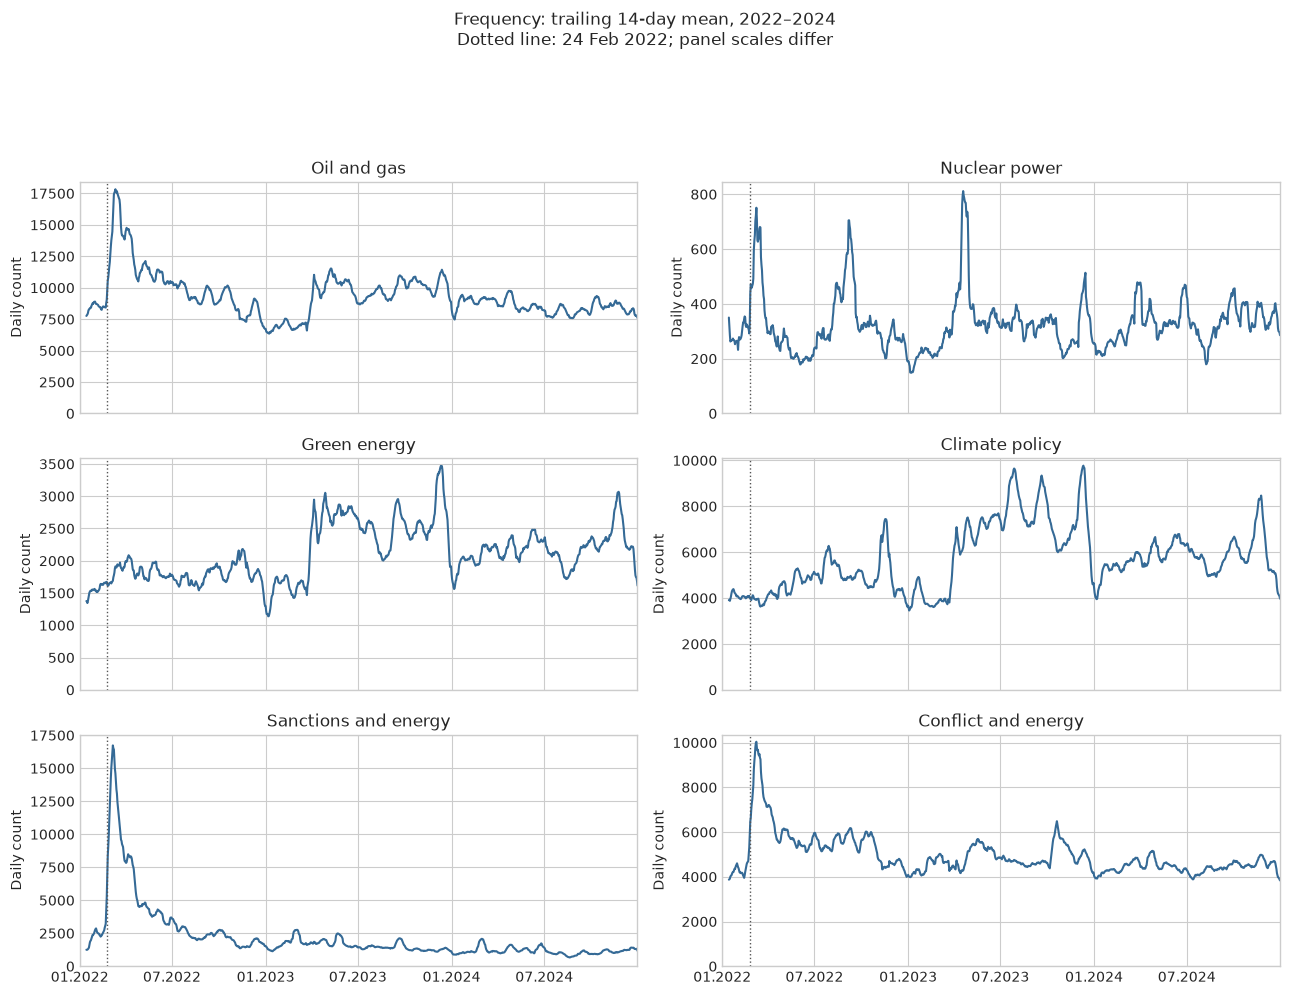

,Oil and gas,Nuclear power,Green energy,Climate policy,Sanctions and energy,Conflict and energy
date,,,,,,
2022,10100.0,325.0,1757.0,4690.0,3821.0,5534.0
2023,9290.0,324.0,2359.0,6583.0,1570.0,4826.0
2024,8510.0,329.0,2166.0,5783.0,1146.0,4432.0


fossil_energy_count      -15.7
nuclear_power_count        1.1
green_energy_count        23.2
climate_policy_count      23.3
sanctions_energy_count   -70.0
conflict_energy_count    -19.9
dtype: float64

In [5]:
fig,axes = plt.subplots(3,2,figsize=(13,10),sharex=True)
for ax,t in zip(axes.flat,TOPICS):
    ax.plot(data.date,data[t+'_count'].rolling(14).mean(),color=BLUE)
    ax.axvline(pd.Timestamp('2022-02-24'),color='#555555',ls=':',lw=1)
    ax.set(title=LABELS[t],ylabel='Daily count',ylim=(0,None))
fig.suptitle('Frequency: trailing 14-day mean, 2022–2024\nDotted line: 24 Feb 2022; panel scales differ',y=0.99)
finish(fig,'02_frequency',rect=[0,0,1,0.91])
annual = data.groupby(data.date.dt.year)[count_cols].mean()
display(annual.rename(columns={t+'_count':LABELS[t] for t in TOPICS}).round(0))
change = (annual.loc[2024]/annual.loc[2022]-1)*100
display(change.round(1))

The mean daily sanctions count in 2024 is 70.0% lower than in 2022; the oil and gas count is 15.7% lower. The annual mean climate policy count peaks in 2023. Daily means are compared rather than annual totals because 2024 contains one additional day. Without total news volume, these changes cannot be interpreted as changes in the topics’ share of media coverage. Several series show abrupt changes near the start of 2023 and 2024.

### 2.2. Tone Trends

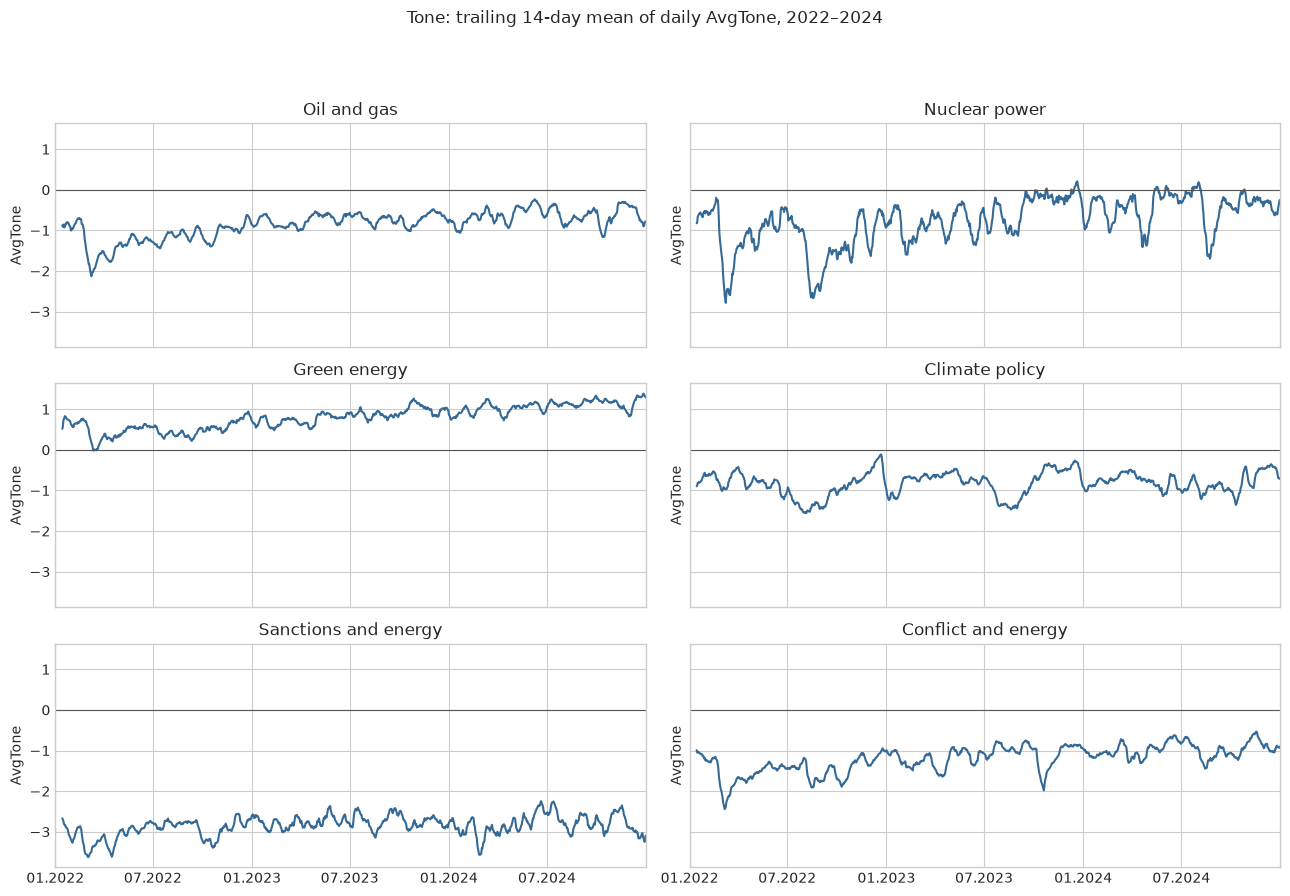

In [6]:
fig,axes = plt.subplots(3,2,figsize=(13,9),sharex=True,sharey=True)
for ax,t in zip(axes.flat,TOPICS):
    ax.plot(data.date,data[t+'_tone'].rolling(14).mean(),color=BLUE)
    ax.axhline(0,color='#555555',lw=.8)
    ax.set(title=LABELS[t],ylabel='AvgTone')
fig.suptitle('Tone: trailing 14-day mean of daily AvgTone, 2022–2024',y=0.99)
finish(fig,'03_tone',rect=[0,0,1,0.94])
means = data[tone_cols].mean()


Green energy has a positive mean daily tone (0.80 AvgTone), while sanctions have the most negative mean (−2.85). Each day receives equal weight. These are not article-weighted averages: the number of documents with valid tone values is unknown. Negative tone also does not necessarily indicate opposition to energy technologies; documents may discuss war, risks, or losses.

## 3. Relationships Between Indicators
### 3.1. Frequency Correlation Matrix

Pearson’s r measures linear association. Values close to 1 indicate strong positive co-movement; values close to 0 indicate weak linear association. The diagonal entries are all 1.

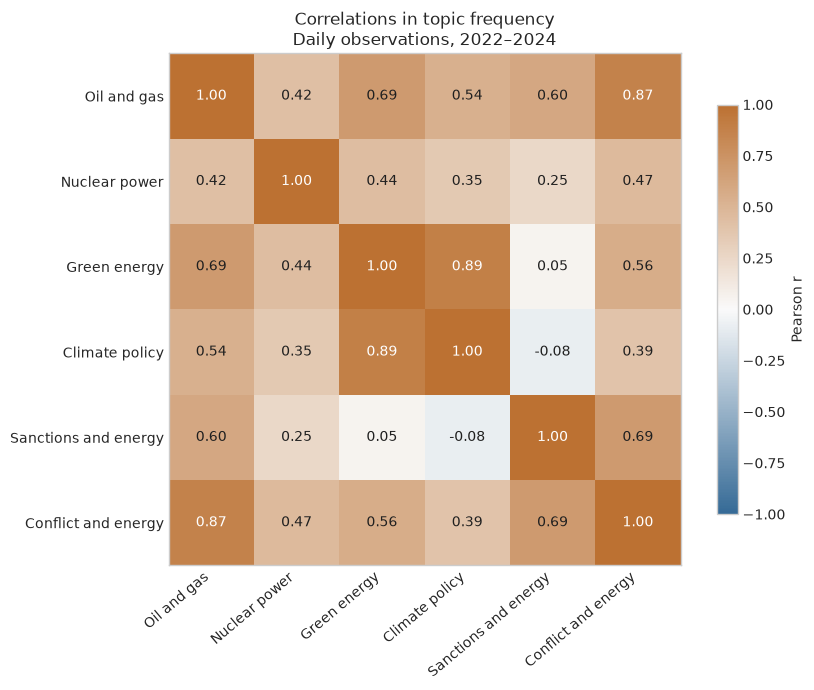

In [7]:
count_corr = data[count_cols].corr()
heatmap(count_corr,'Correlations in topic frequency','04_count_heatmap')

The strongest frequency correlation is between green energy and climate policy (r = 0.89). Oil and gas and the conflict topic are almost as strongly correlated (r = 0.87). The association between sanctions and climate policy is weak (r = −0.08).

The strong correlations may reflect shared news coverage and overlapping documents. Common trends and weekly patterns may also increase correlations. The matrix does not establish causal relationships between topics.

### 3.2. Tone Correlation Matrix

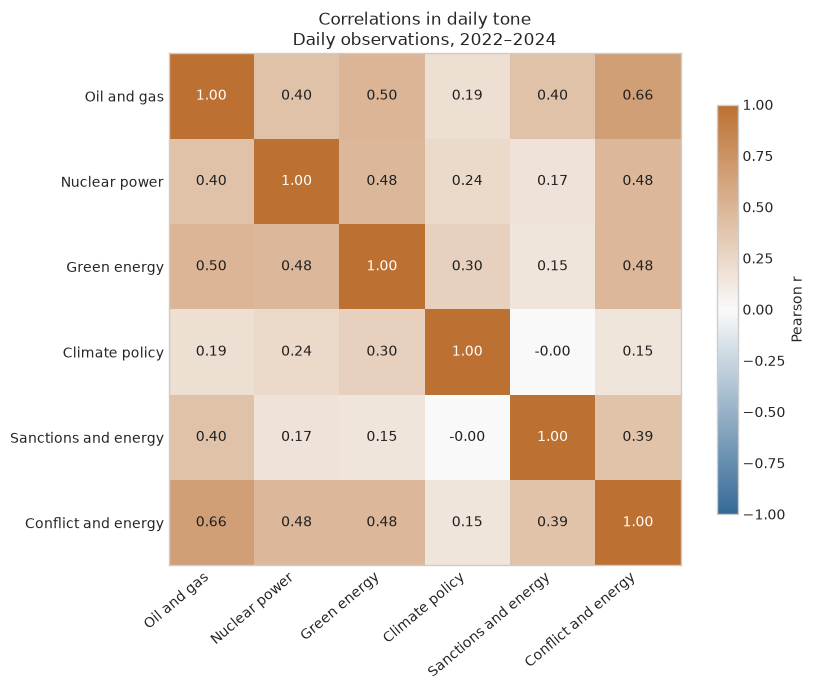

In [8]:
tone_corr = data[tone_cols].corr()
heatmap(tone_corr,'Correlations in daily tone','05_tone_heatmap')

The strongest tone correlation is between oil and gas and the conflict topic (r = 0.66). For green energy and climate policy, the tone correlation is only 0.30, compared with 0.89 for frequency. Co-movement in mention counts does not necessarily imply similar changes in tone. The linear association between climate policy tone and sanctions tone is close to zero.

### 3.3. Associations Between Changes in Frequency and Tone Within Topics

This section compares changes in count and tone for **the same topic on the same day**.

Spearman’s ρ is used. Uncertainty is approximated using rank regressions with HAC standard errors and maximum lags of 14 and 28 days.

The Benjamini–Hochberg adjustment is applied across the six topics separately for each HAC bandwidth to control the false discovery rate.

In [9]:
correlations = differenced_topic_correlations(data)
display(correlations.set_index('topic').rename(index=LABELS).style.format(
    {c:'{:.2e}' for c in correlations if c.startswith(('p_','q_'))},precision=3))
correlations.to_csv(TABLES/'daily_change_correlations.csv',index=False)

,spearman_rho,p_hac_14,p_hac_28,q_hac_14,q_hac_28
topic,,,,,
Climate policy,0.267,1.87e-24,7.85e-23,1.12e-23,4.71e-22
Green energy,0.227,2.05e-18,9.68e-18,6.14e-18,2.91e-17
Conflict and energy,0.093,7.05e-03,1.16e-02,1.41e-02,2.22e-02
Sanctions and energy,-0.076,1.38e-02,1.48e-02,2.08e-02,2.22e-02
Nuclear power,-0.009,8.30e-01,8.44e-01,8.30e-01,8.44e-01
Oil and gas,0.008,8.10e-01,8.12e-01,8.30e-01,8.44e-01


The largest positive associations are observed for climate policy (ρ = 0.27) and green energy (ρ = 0.23). Increases in counts tend to coincide with more positive changes in tone, although the associations are moderate. For sanctions and conflict, the absolute coefficients are below 0.10; small p-values do not imply strong associations. There is no convincing contemporaneous association for oil and gas or nuclear power. Lagged relationships are examined separately in H4.

## 4. Hypothesis Assessment
### H1. Changes Around 24 February 2022

The model compares observations before and after 24 February, controlling for the preceding trend and day-of-week differences. It estimates a shift coinciding with this date; it does not establish that the event caused the shift.

HAC standard errors account for heteroskedasticity and serial dependence with a maximum lag of 14 days.

Counts are analysed on the `log(1 + count)` scale, so percentage changes refer to `count + 1`. Tone changes are measured in AvgTone points. The intervals are 95% confidence intervals, and q-values adjust for the four H1 tests.

Sensitivity is assessed using windows of ±30, ±60, and ±90 days. The main window contains only 54 pre-event days because the data begin on 1 January 2022. There are 61 post-event observations, including 24 February.

In [10]:
rows, sensitivity = [], []
for t in ('conflict_energy','sanctions_energy'):
    for suffix in ('count','tone'):
        function = event_study_hac if suffix=='count' else event_study_level_hac
        for window in (30,60,90):
            r = function(data,t+'_'+suffix,'2022-02-24',window_days=window)
            r = {k.replace('_pct',''):v for k,v in r.items()}
            r.update(topic=LABELS[t],unit='%' if suffix=='count' else 'AvgTone',window=window)
            sensitivity.append(r)
            if window==60: rows.append(r.copy())
h1 = pd.DataFrame(rows)
h1['q_value'] = benjamini_hochberg(h1.p_value_hac)
h1_sensitivity = pd.DataFrame(sensitivity)
display(h1[['topic','unit','level_change','ci_low','ci_high','q_value','n_days']].style.format({'q_value':'{:.2e}'},precision=2))
display(h1_sensitivity.pivot(index='outcome',columns='window',values='level_change').round(2))
h1.to_csv(TABLES/'h1.csv',index=False)
h1_sensitivity.to_csv(TABLES/'h1_window_sensitivity.csv',index=False)

,topic,unit,level_change,ci_low,ci_high,q_value,n_days
0,Conflict and energy,%,98.02,67.65,133.89,3.52e-15,115
1,Conflict and energy,AvgTone,-0.81,-1.08,-0.54,6.30e-09,115
2,Sanctions and energy,%,246.61,140.89,398.73,4.29e-11,115
3,Sanctions and energy,AvgTone,-0.01,-0.37,0.36,9.77e-01,115


window,30,60,90
outcome,,,
conflict_energy_count,92.73,98.02,79.45
conflict_energy_tone,-1.03,-0.81,-0.72
sanctions_energy_count,293.38,246.61,200.75
sanctions_energy_tone,-0.19,-0.01,-0.05


In the main specification, the conflict count shows a shift of approximately +98% and the sanctions count approximately +247%, relative to the continuation of the local trend. Conflict tone decreases by approximately 0.81 points; the model does not identify a statistically significant shift in sanctions tone.

The estimates depend on the window length. They are not interpreted as precise causal effects of the invasion: events in late February and March overlap, and the pre-event history is short. The estimated discontinuity is also distinct from the average change over the entire post-event period.

### H2. Nuclear and Green Energy Coverage Around Major Events

All eight events are included in a single model. Three intervals are considered for each event: days 0–7, 8–14, and 15–30 after the event.

The model controls for counts lagged by one and seven days, an overall trend, day-of-week differences, and annual seasonality. Each coefficient therefore represents a conditional deviation from the expected count in that interval. It does not represent the cumulative change over a month. Percentages refer to `count + 1` and cannot be added to obtain a monthly percentage change.

REPowerEU is dated 18 May 2022, and the twelfth EU sanctions package is dated 18 December 2023. See the [event date sources](../reports/event_sources.md). The selected events are reference points for this exploratory analysis, rather than a complete list of energy crises.

topic,green_energy,nuclear_power
event,,
12th EU sanctions package,1.78e-03,3.33e-03
Hamas attack,1.21e-01,5.00e-06
Nord Stream explosions,2.00e-09,7.64e-01
OPEC+ announcement,2.73e-02,1.31e-07
Oil price cap takes effect,1.61e-03,7.69e-05
REPowerEU plan,1.61e-03,2.87e-25
Russia’s invasion of Ukraine,1.85e-01,3.56e-05
US energy import ban,4.18e-02,1.14e-03


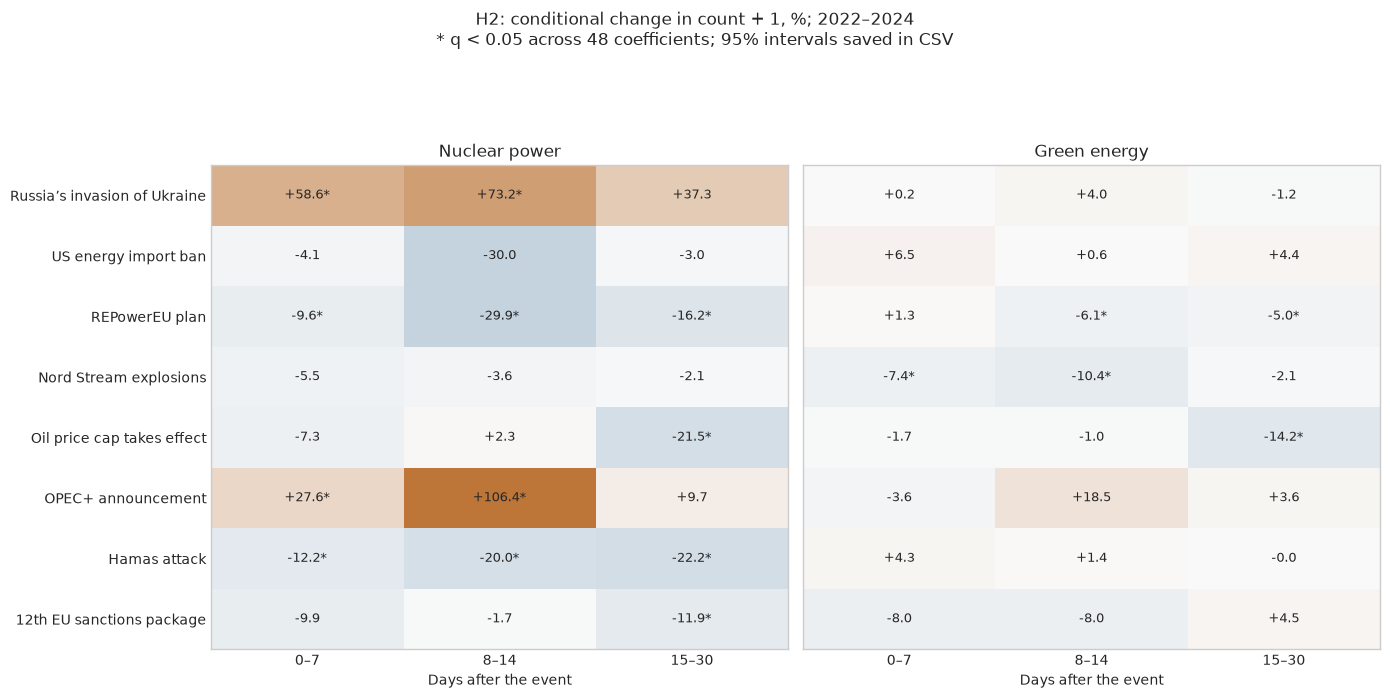

In [11]:
ENERGY_EVENTS = {
    '2022-02-24':'Russia’s invasion of Ukraine', '2022-03-08':'US energy import ban',
    '2022-05-18':'REPowerEU plan', '2022-09-26':'Nord Stream explosions',
    '2022-12-05':'Oil price cap takes effect', '2023-04-02':'OPEC+ announcement',
    '2023-10-07':'Hamas attack', '2023-12-18':'12th EU sanctions package'}
coefs,joints = [],[]
for t in ('nuclear_power','green_energy'):
    c,j = multi_event_distributed_lag(data,t+'_count',ENERGY_EVENTS)
    coefs.append(c.assign(topic=t)); joints.append(j.assign(topic=t))
h2,h2_joint = pd.concat(coefs,ignore_index=True),pd.concat(joints,ignore_index=True)
# Families span both topics: 48 coefficients and 16 joint tests.
h2['p_value_fdr'] = benjamini_hochberg(h2.p_value)
h2_joint['joint_p_fdr'] = benjamini_hochberg(h2_joint.joint_p_value)
display(h2_joint.pivot(index='event',columns='topic',values='joint_p_fdr').style.format('{:.2e}'))
h2.to_csv(TABLES/'h2_lag_coefficients.csv',index=False)
h2_joint.to_csv(TABLES/'h2_joint_tests.csv',index=False)
fig,axes = plt.subplots(1,2,figsize=(14,7),sharey=True)
limit = max(10,np.ceil(h2.effect_pct.abs().max()/10)*10)
for ax,t in zip(axes,('nuclear_power','green_energy')):
    part = h2.loc[h2.topic==t]
    m = part.pivot(index='event',columns='lag_bin',values='effect_pct').reindex(list(ENERGY_EVENTS.values()))[['0–7','8–14','15–30']]
    q = part.pivot(index='event',columns='lag_bin',values='p_value_fdr').reindex(m.index)[m.columns]
    ax.imshow(m,cmap=CMAP,vmin=-limit,vmax=limit,aspect='auto')
    ax.grid(False)
    ax.set_xticks(range(3),m.columns); ax.set_yticks(range(8),m.index)
    ax.set(title=LABELS[t],xlabel='Days after the event')
    for i in range(8):
        for j in range(3):
            star = '*' if q.iloc[i,j]<.05 else ''
            ax.text(j,i,f'{m.iloc[i,j]:+.1f}{star}',ha='center',va='center',fontsize=9)
fig.suptitle('H2: conditional change in count + 1, %; 2022–2024\n* q < 0.05 across 48 coefficients; 95% intervals saved in CSV',y=0.99)
finish(fig,'06_h2',rect=[0,0,1,0.90])


At least one of the three intervals differs from the model baseline for 13 of the 16 event–topic combinations. After adjustment for multiple testing, 4 positive and 13 negative interval coefficients are statistically significant. The results do not indicate a consistent increase in coverage of alternative energy after every crisis. Asterisks on the heatmap mark coefficients that remain significant after adjustment. The February and March events are close in time, making their contributions difficult to separate. Multiple-testing adjustment does not remove bias arising from selecting events after inspecting the data.

**An overlapping event in H2.** The large nuclear coefficient for days 8–14 after the OPEC+ announcement overlaps with the closure of Germany’s last three nuclear power plants on 15 April 2023. That event is not included as a separate control. The entire shift therefore cannot be attributed to OPEC+; the [source for the closure date](../reports/event_sources.md) documents this overlap.

### H3. Climate Coverage Around COP Summits

Observations around COP27, COP28, and COP29 are pooled by time relative to the opening date. The baseline comprises days outside the five specified windows, controlling for trend, seasonality, and lags of one and seven days. The coefficients are shared across the three summits and do not establish identical responses at each COP. Opening dates are documented by [UNFCCC](../reports/event_sources.md).

,event_time,effect_pct,ci_low_pct,ci_high_pct,p_value,p_value_fdr
0,lead_30_15,-0.54,-5.18,4.32,8.24e-01,8.24e-01
1,lead_14_1,6.33,2.13,10.71,2.85e-03,7.12e-03
2,event_0_6,18.75,9.72,28.52,2.07e-05,1.04e-04
3,lag_7_14,4.72,-1.96,11.86,1.71e-01,2.13e-01
4,lag_15_30,-6.08,-11.07,-0.80,2.46e-02,4.09e-02


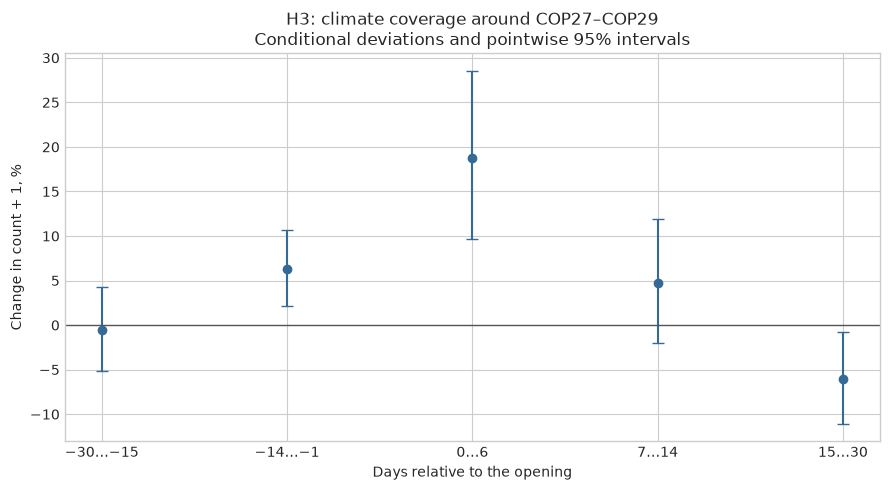

In [12]:
COP_EVENTS = {'2022-11-06':'COP27','2023-11-30':'COP28','2024-11-11':'COP29'}
h3 = cop_event_time_model(data,'climate_policy_count',COP_EVENTS)
display(h3.style.format({'p_value':'{:.2e}','p_value_fdr':'{:.2e}'},precision=2))
h3.to_csv(TABLES/'h3.csv',index=False)
fig,ax = plt.subplots(figsize=(9,5))
ax.errorbar(['−30…−15','−14…−1','0…6','7…14','15…30'],h3.effect_pct,
    yerr=[h3.effect_pct-h3.ci_low_pct,h3.ci_high_pct-h3.effect_pct],fmt='o',color=BLUE,capsize=4)
ax.axhline(0,color='#555555',lw=1)
ax.set(title='H3: climate coverage around COP27–COP29\nConditional deviations and pointwise 95% intervals',
       xlabel='Days relative to the opening',ylabel='Change in count + 1, %')
finish(fig,'07_h3')

The model estimates a deviation of +6.3% in the two weeks before the opening and +18.7% in the first week; both remain significant after FDR adjustment across the five intervals. The coefficient for days 15–30 is negative. This pattern is consistent with increased coverage before and at the start of a summit, followed by a decline.

Only three COP summits are included, and all take place at approximately the same time of year. The findings describe the observed period; generalisation requires additional observations. These are conditional coefficients holding lagged values fixed, rather than the total increase in publications over a summit.

### H4. Does Tone Precede Changes in Frequency?

First differences of `log(1 + count)` and AvgTone are used for all topics. Stationarity is assessed using ADF tests, and the VAR lag order is selected by AIC, with a maximum of 14 days. The Granger test assesses whether past changes in tone provide additional information about count changes after controlling for the count’s own lags. It is an in-sample test, rather than an evaluation of predictions on new data.

VAR stability and residual autocorrelation up to 28 days are also assessed. Without these diagnostics, nominal significance may be misleading. Failure to establish stationarity in levels does not by itself demonstrate integration of order one and justify an automatic switch to VECM.

In [13]:
h4 = var_changes_by_topic(data)
display(h4.set_index('topic').rename(index=LABELS).style.format(
    {c:'{:.2e}' for c in h4 if c.startswith('adf_p') or c.endswith(('_p','_q'))},precision=3))
h4.to_csv(TABLES/'h4_diagnostics.csv',index=False)


,adf_p_count_change,adf_p_tone_change,lag,tone_to_count_p,stable,whiteness_p,status,tone_to_count_q
topic,,,,,,,,
Oil and gas,1.27e-16,4.05e-25,14,3.22e-08,True,7.72e-10,residual dependence or instability,4.82e-08
Nuclear power,1.16e-17,1.98e-24,13,1.15e-03,True,6.44e-05,residual dependence or instability,1.38e-03
Green energy,8.02e-16,4.77e-23,14,1.99e-08,True,2.22e-12,residual dependence or instability,4.82e-08
Climate policy,2.73e-16,1.12e-17,14,2.75e-08,True,1.70e-11,residual dependence or instability,4.82e-08
Sanctions and energy,5.85e-17,7.83e-25,14,7.58e-02,True,1.41e-08,residual dependence or instability,7.58e-02
Conflict and energy,1.84e-13,8.21e-21,14,5.44e-15,True,1.41e-09,residual dependence or instability,3.27e-14


The `tone_to_count_p` and `tone_to_count_q` columns assess whether past changes in tone help explain changes in frequency after controlling for the frequency’s own past values.

After adjustment across the six topics, five topics have q < 0.05. For sanctions and energy, q = 0.0758, above the 0.05 threshold. These results concern in-sample associations; they do not establish causality or out-of-sample forecast accuracy.

**Why H4 is not considered supported**

- `stable` is True for all six models, indicating stability under this diagnostic.
- `whiteness_p` is very small for all six models, indicating that serial dependence remains in the residuals.

Although `status` reads “residual dependence or instability”, all models have `stable=True`. The diagnostic failure in these results therefore concerns residual dependence rather than instability. Remaining serial dependence can make nominal significance unreliable; small q-values do not resolve this issue.

The `adf_p_count_change` and `adf_p_tone_change` columns report ADF results for the transformed series. Their small values support rejection of the unit-root null after first differencing. The selected lag orders are 13–14 days.

The next section evaluates weekly forecasts on a separate test sample for 2024.

### Additional Assessment of the Predictive Value of Tone

Data are aggregated into complete weeks: weekly counts are sums of daily counts, and weekly tone is the mean of daily tone values. Models are selected using weeks in 2022–2023 only; 2024 is reserved for testing.

Two models predict changes in weekly `log(1 + count)`: a baseline AR uses only past count changes, while a VAR also uses past tone changes. Lag orders are selected on the training sample. For the VAR, selection favours stable models without detected residual autocorrelation; residual diagnostics are also reported for the baseline model.

On the test sample, one-week-ahead forecasts are generated sequentially. After each week, its observed values become available for the next forecast, but model parameters are not re-estimated. Errors are evaluated on the weekly `log(1 + count)` level scale. Uncertainty in the VAR’s forecast improvement is estimated using a block bootstrap with four-week blocks.

In [14]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.stats.diagnostic import acorr_ljungbox

forecast_data = data.set_index('date')
forecast_rows = []
forecast_rng = np.random.default_rng(20260930)
for topic in TOPICS:
    count_col, tone_col = topic+'_count', topic+'_tone'
    weekly = forecast_data[[count_col, tone_col]].resample('W-SUN').agg(
        {count_col:'sum', tone_col:'mean'})
    full_week = forecast_data[count_col].resample('W-SUN').size().eq(7)
    weekly = weekly.loc[full_week]
    log_count = np.log1p(weekly[count_col])
    changes = pd.DataFrame({
        'count':log_count.diff(),
        'tone':weekly[tone_col].diff(),
    }).dropna()
    train = changes.loc[changes.index < '2024-01-01']
    test = changes.loc[changes.index >= '2024-01-01']

    ar_candidates = []
    for lag in range(1,9):
        fit = AutoReg(train['count'],lags=lag,trend='c').fit()
        white_p = float(acorr_ljungbox(
            fit.resid,lags=[12],return_df=True)['lb_pvalue'].iloc[0])
        ar_candidates.append((fit,lag,white_p))
    ar_passing = [candidate for candidate in ar_candidates if candidate[2]>=.05]
    ar_fit, ar_lag, ar_white_p = min(
        ar_passing or ar_candidates,key=lambda candidate:candidate[0].aic)

    var_candidates = []
    for lag in range(1,9):
        fit = VAR(train).fit(lag,trend='c')
        stable = bool(fit.is_stable())
        white_p = float(fit.test_whiteness(nlags=12,adjusted=True).pvalue)
        var_candidates.append((fit,lag,stable,white_p))
    var_passing = [candidate for candidate in var_candidates
                   if candidate[2] and candidate[3]>=.05]
    var_fit, var_lag, var_stable, var_white_p = min(
        var_passing or var_candidates,key=lambda candidate:candidate[0].aic)

    count_history = train['count'].to_numpy().tolist()
    pair_history = train[['count','tone']].to_numpy().tolist()
    ar_predictions, var_predictions = [],[]
    ar_params = ar_fit.params.to_numpy()
    for actual in test[['count','tone']].to_numpy():
        ar_predictions.append(ar_params[0]+sum(
            ar_params[offset+1]*count_history[-(offset+1)]
            for offset in range(ar_lag)))
        var_predictions.append(var_fit.forecast(
            np.asarray(pair_history[-var_lag:]),steps=1)[0,0])
        count_history.append(float(actual[0]))
        pair_history.append([float(actual[0]),float(actual[1])])

    actual_level = log_count.loc[test.index].to_numpy()
    previous_level = log_count.shift(1).loc[test.index].to_numpy()
    error_ar = previous_level+np.asarray(ar_predictions)-actual_level
    error_var = previous_level+np.asarray(var_predictions)-actual_level
    rmse_ar = float(np.sqrt(np.mean(error_ar**2)))
    rmse_var = float(np.sqrt(np.mean(error_var**2)))

    bootstrap_skill = []
    test_size, block_size = len(test),4
    for _ in range(2000):
        starts = forecast_rng.integers(
            0,test_size,size=int(np.ceil(test_size/block_size)))
        indices = np.concatenate([
            (start+np.arange(block_size))%test_size for start in starts
        ])[:test_size]
        sampled_ar = np.sqrt(np.mean(error_ar[indices]**2))
        sampled_var = np.sqrt(np.mean(error_var[indices]**2))
        bootstrap_skill.append(100*(1-sampled_var/sampled_ar))

    forecast_rows.append({
        'topic':topic,'train_weeks':len(train),'test_weeks':len(test),
        'ar_lag':ar_lag,'ar_whiteness_p':ar_white_p,
        'var_lag':var_lag,'var_stable':var_stable,
        'var_whiteness_p':var_white_p,
        'rmse_count_only':rmse_ar,'rmse_count_plus_tone':rmse_var,
        'rmse_skill_pct':100*(1-rmse_var/rmse_ar),
        'skill_ci_low_pct':float(np.quantile(bootstrap_skill,.025)),
        'skill_ci_high_pct':float(np.quantile(bootstrap_skill,.975)),
        'residual_checks_passed':bool(
            ar_white_p>=.05 and var_stable and var_white_p>=.05),
    })

h4_forecast = pd.DataFrame(forecast_rows)
display(h4_forecast.set_index('topic').rename(index=LABELS).style.format({
    'ar_whiteness_p':'{:.3f}','var_whiteness_p':'{:.3f}',
    'rmse_count_only':'{:.3f}','rmse_count_plus_tone':'{:.3f}',
    'rmse_skill_pct':'{:+.1f}%','skill_ci_low_pct':'{:+.1f}%',
    'skill_ci_high_pct':'{:+.1f}%',
}))
h4_forecast.to_csv(TABLES/'h4_forecast_holdout.csv',index=False)

,train_weeks,test_weeks,ar_lag,ar_whiteness_p,var_lag,var_stable,var_whiteness_p,rmse_count_only,rmse_count_plus_tone,rmse_skill_pct,skill_ci_low_pct,skill_ci_high_pct,residual_checks_passed
topic,,,,,,,,,,,,,
Oil and gas,103,52,1,0.724,3,True,0.312,0.080,0.085,-5.1%,-16.8%,+3.7%,True
Nuclear power,103,52,7,0.948,1,True,0.176,0.277,0.271,+2.1%,-7.1%,+9.4%,True
Green energy,103,52,2,0.142,2,True,0.335,0.122,0.124,-1.7%,-7.6%,+4.2%,True
Climate policy,103,52,1,0.751,1,True,0.693,0.125,0.123,+1.6%,+0.1%,+3.1%,True
Sanctions and energy,103,52,8,0.393,2,True,0.371,0.221,0.230,-3.8%,-13.1%,+4.3%,True
Conflict and energy,103,52,8,0.932,6,True,0.072,0.071,0.076,-7.4%,-21.3%,+9.1%,True


All six selected AR and VAR model pairs pass the specified training-sample residual checks. Across the 52 test weeks in 2024, adding tone reduces RMSE for two topics and increases it for four. The block-bootstrap 95% interval for improvement excludes zero only for climate policy; the gain is small, and no adjustment for comparing six topics is applied. These results do not establish a robust forecasting benefit from tone: they cover one test year and remain exploratory.

### Descriptive Assessment of Lagged Associations

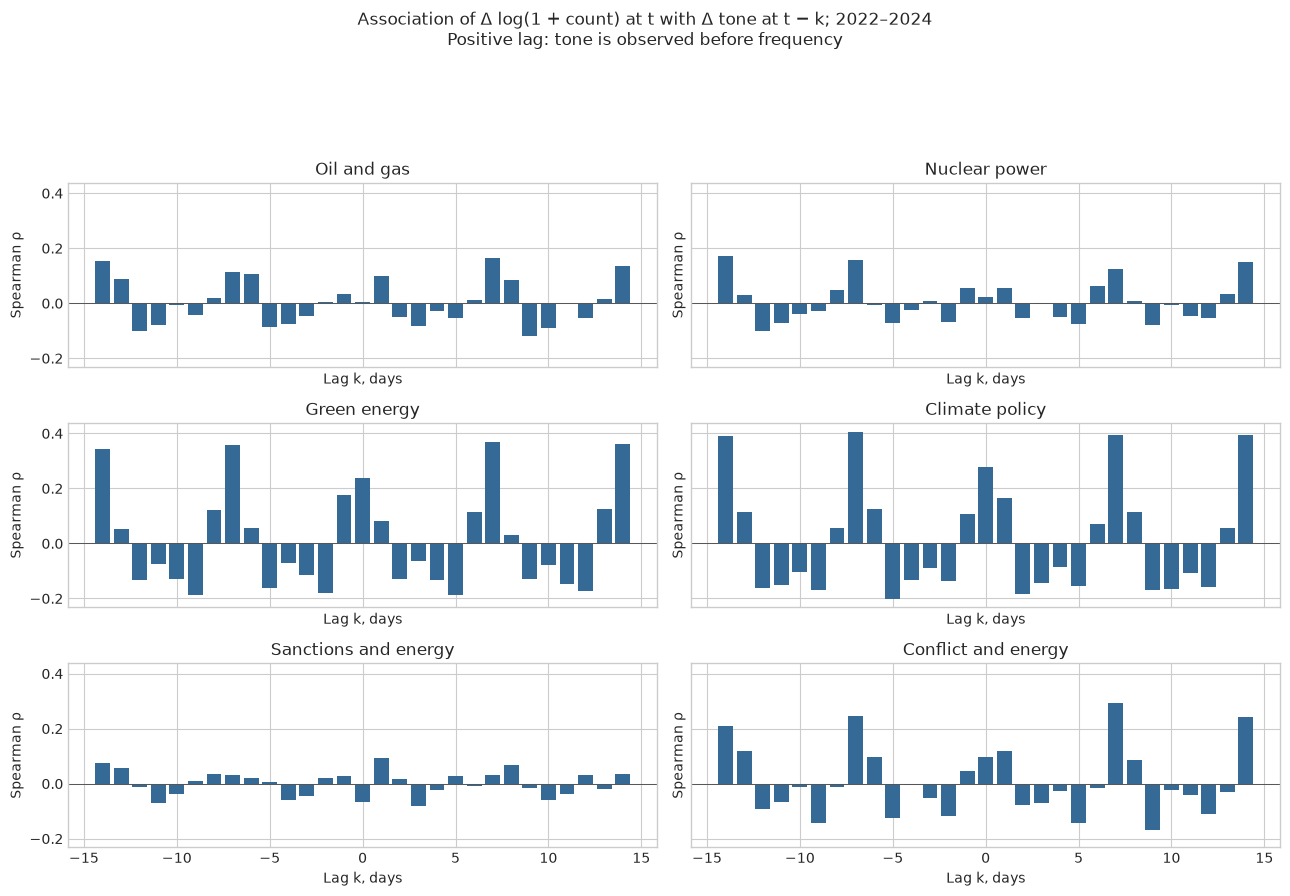

In [15]:
fig,axes = plt.subplots(3,2,figsize=(13,9),sharex=True,sharey=True)
for ax,t in zip(axes.flat,TOPICS):
    dc,dt = np.log1p(data[t+'_count']).diff(),data[t+'_tone'].diff()
    correlations_lag = [dc.corr(dt.shift(k),method='spearman') for k in range(-14,15)]
    ax.bar(range(-14,15),correlations_lag,color=BLUE)
    ax.axhline(0,color='#555555',lw=.7)
    ax.set(title=LABELS[t],ylabel='Spearman ρ',xlabel='Lag k, days')
fig.suptitle('Association of Δ log(1 + count) at t with Δ tone at t − k; 2022–2024\nPositive lag: tone is observed before frequency',y=0.99)
finish(fig,'08_lags',rect=[0,0,1,0.90])

Green energy and climate policy show positive peaks near lags −14, −7, +7, and +14 days. Repetition in both directions is consistent with a shared weekly pattern, rather than solely with tone preceding frequency. Bars to the right of zero refer to past tone, and bars to the left refer to future tone. Selecting the largest bar retrospectively is not a hypothesis test: no confidence intervals or adjustment for examining multiple lags are provided. Lagged correlations do not resolve the residual autocorrelation identified in the VAR models.

### Conclusions

**Co-movement in frequency is stronger than co-movement in tone.** For green energy and climate policy, the frequency correlation is approximately 0.89, compared with approximately 0.30 for tone.

**Event-related patterns vary.** H1 identifies increases in both counts and a decline in conflict tone; the change in sanctions tone is not statistically significant. In H2, the direction and duration of deviations vary across events and topics. In H3, the largest positive coefficient corresponds to the first week of COP.

**Predictive value remains inconclusive.** The daily VAR models show nominally significant results, but their residual diagnostics limit interpretation. The hypothesis therefore remains exploratory.

The main limitation is the quality of the underlying sample. The existing CSV files allow the calculations to be reproduced and associations to be described. Claims about individual articles, countries, or causal event effects require validated topic definitions, source documents, and a comparable control series. More complex models do not replace these requirements.

### Reproduction and Sources

The notebook is edited directly. To execute all cells and save their outputs, run `python scripts/run_notebook.py` from the project root. Figures are saved in `reports/figures` and calculated tables in `reports/tables`; the raw CSV files are unchanged.

- [GDELT GKG 2.1 field documentation](https://data.gdeltproject.org/documentation/GDELT-Global_Knowledge_Graph_Codebook-V2.1.pdf).
- [SQL](../sql/gdelt_energy_unified.sql).
- [Event date sources](../reports/event_sources.md).